<a href="https://colab.research.google.com/github/Cumikkk/feature-extraction/blob/main/feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
!pip install ultralytics -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files

In [92]:
image_filename = "/content/kendaraan di jalan tol.jpg"
print(f"File: {image_filename}")

File: /content/kendaraan di jalan tol.jpg


In [93]:
model = YOLO("yolov8n-seg.pt")

image_bgr = cv2.imread(image_filename)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

results = model(image_rgb, conf=0.4)
result = results[0]

print(f"Jumlah objek terdeteksi: {len(result.boxes)}")
for i, box in enumerate(result.boxes):
    cls_id = int(box.cls[0])
    label = model.names[cls_id]
    conf = float(box.conf[0])
    print(f"  Objek {i+1}: {label} ({conf:.2f})")


0: 320x640 5 cars, 1 truck, 173.3ms
Speed: 2.8ms preprocess, 173.3ms inference, 10.6ms postprocess per image at shape (1, 3, 320, 640)
Jumlah objek terdeteksi: 6
  Objek 1: car (0.78)
  Objek 2: car (0.77)
  Objek 3: car (0.72)
  Objek 4: car (0.62)
  Objek 5: car (0.45)
  Objek 6: truck (0.44)


In [94]:
COLORS = [
    (255, 0,   0),
    (0,   200, 0),
    (0,   0,   255),
    (255, 200, 0),
    (255, 0,   200),
    (0,   200, 255),
    (128, 0,   255),
    (255, 128, 0),
]

orig_h, orig_w = image_rgb.shape[:2]

# Tahap 0: canny edge
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
canny = cv2.Canny(blurred, 50, 150)
canny_rgb = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)

# Tahap 0b: kontur canny di-overlay ke gambar asli
combined = image_rgb.copy()
contours_canny, _ = cv2.findContours(canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(combined, contours_canny, -1, (0, 255, 0), 1)

# Tahap 1: bounding box saja, tanpa label
step1 = image_rgb.copy()
for i, box in enumerate(result.boxes):
    color = COLORS[i % len(COLORS)]
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cv2.rectangle(step1, (x1, y1), (x2, y2), color, 2)

# Tahap 2: kontur + fill semi-transparan
# Tahap 3: full fill solid
step2 = image_rgb.copy()
step3 = image_rgb.copy()
overlay2 = image_rgb.copy()
overlay3 = image_rgb.copy()

if result.masks is not None:
    masks = result.masks.data.cpu().numpy()

    for i, (mask, box) in enumerate(zip(masks, result.boxes)):
        color = COLORS[i % len(COLORS)]

        mask_resized = cv2.resize(
            mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST
        )
        mask_bool = mask_resized > 0.5

        overlay2[mask_bool] = color
        overlay3[mask_bool] = color

        mask_uint8 = (mask_bool.astype(np.uint8)) * 255
        contours, _ = cv2.findContours(
            mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.drawContours(step2, contours, -1, color, 2)

    step2 = cv2.addWeighted(overlay2, 0.4, step2, 0.6, 0)
    step3 = overlay3.copy()

else:
    print("Tidak ada mask terdeteksi. Coba turunkan nilai conf di Cell 3.")

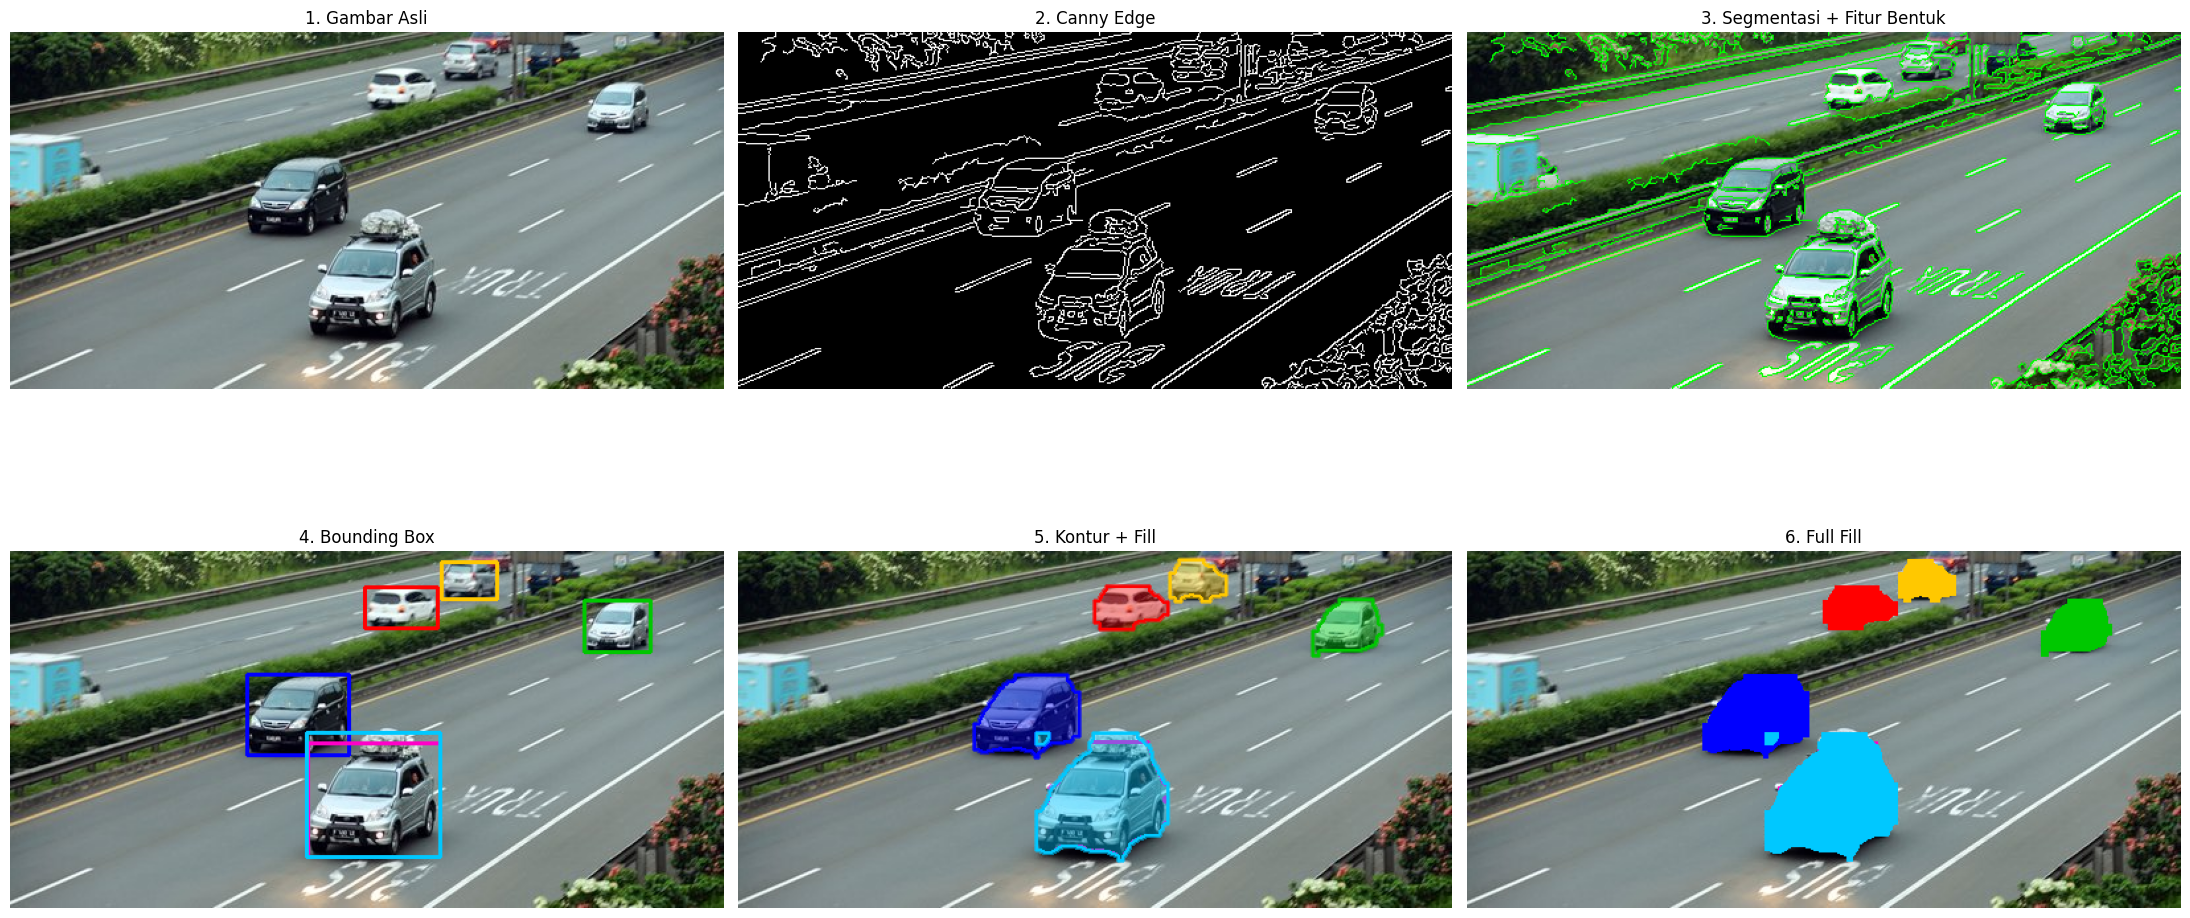

In [95]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title("1. Gambar Asli", fontsize=12)
axes[0, 0].axis("off")

axes[0, 1].imshow(canny_rgb)
axes[0, 1].set_title("2. Canny Edge", fontsize=12)
axes[0, 1].axis("off")

axes[0, 2].imshow(combined)
axes[0, 2].set_title("3. Segmentasi + Fitur Bentuk", fontsize=12)
axes[0, 2].axis("off")

axes[1, 0].imshow(step1)
axes[1, 0].set_title("4. Bounding Box", fontsize=12)
axes[1, 0].axis("off")

axes[1, 1].imshow(step2)
axes[1, 1].set_title("5. Kontur + Fill", fontsize=12)
axes[1, 1].axis("off")

axes[1, 2].imshow(step3)
axes[1, 2].set_title("6. Full Fill", fontsize=12)
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

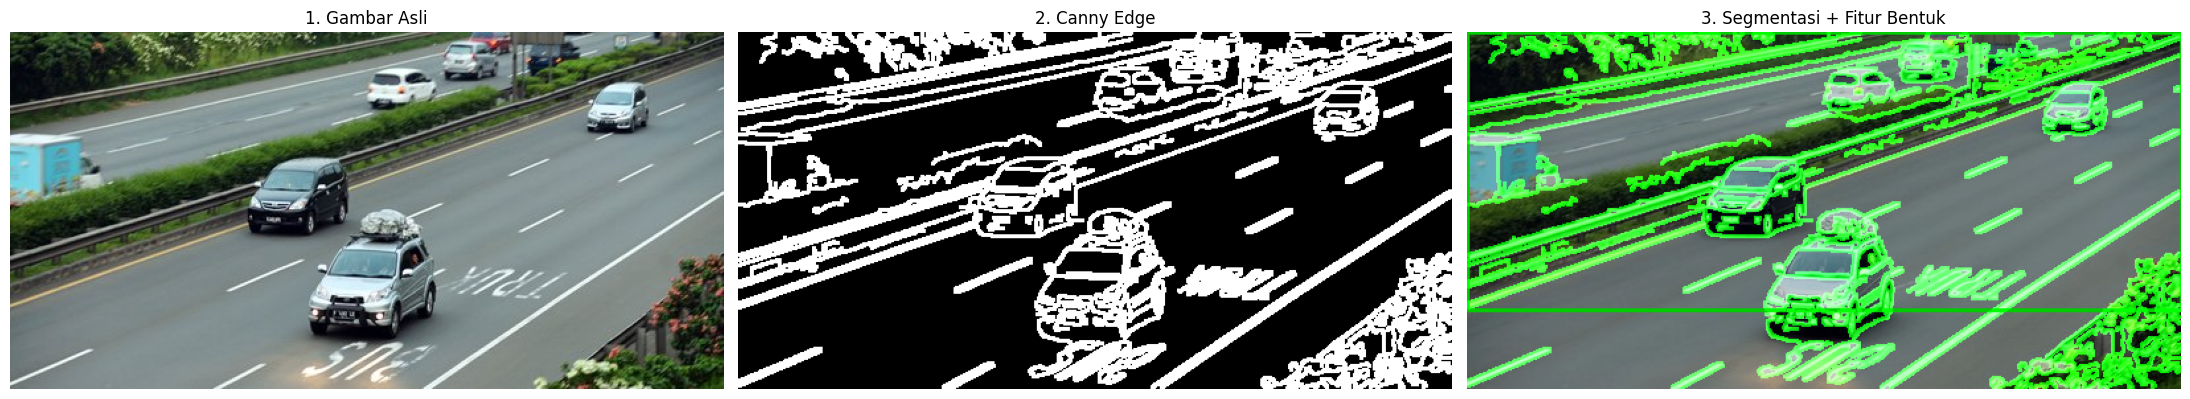

In [96]:
image_bgr2 = cv2.imread(image_filename)
image_rgb2 = cv2.cvtColor(image_bgr2, cv2.COLOR_BGR2RGB)

gray2 = cv2.cvtColor(image_bgr2, cv2.COLOR_BGR2GRAY)
blur2 = cv2.GaussianBlur(gray2, (5, 5), 0)
edges2 = cv2.Canny(blur2, 50, 150)
kernel2 = np.ones((3, 3), np.uint8)
edges2 = cv2.dilate(edges2, kernel2, iterations=1)

contours2, _ = cv2.findContours(edges2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

canny_display2 = cv2.cvtColor(edges2, cv2.COLOR_GRAY2RGB)

output_features2 = image_rgb2.copy()
green_edges2 = np.zeros_like(image_rgb2)
green_edges2[:, :, 1] = edges2

for cnt in contours2:
    area = cv2.contourArea(cnt)
    if area > 8000:
        perimeter = cv2.arcLength(cnt, True)
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)
        circularity = (4 * np.pi * area / (perimeter ** 2)) if perimeter != 0 else 0
        if 1.2 < aspect_ratio < 4.5:
            cv2.rectangle(output_features2, (x, y), (x + w, y + h), (0, 255, 0), 2)
            text = f"A:{int(area)} AR:{aspect_ratio:.2f}"
            cv2.putText(output_features2, text, (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

combined2 = cv2.addWeighted(output_features2, 0.8, green_edges2, 0.8, 0)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].imshow(image_rgb2)
axes[0].set_title("1. Gambar Asli", fontsize=12)
axes[0].axis("off")

axes[1].imshow(canny_display2)
axes[1].set_title("2. Canny Edge", fontsize=12)
axes[1].axis("off")

axes[2].imshow(combined2)
axes[2].set_title("3. Segmentasi + Fitur Bentuk", fontsize=12)
axes[2].axis("off")

plt.tight_layout()
plt.show()